In [2]:
from google.colab import files
uploaded = files.upload()

Saving film-emotion-music-datasheet.csv to film-emotion-music-datasheet.csv


In [ ]:
import pandas as pd

df = pd.read_csv("per-song-fme.csv")

df.head()

,participant_id,date_time,path,emotion_sentence,familiarity,AV,timestamps,number_of_annotations,Unnamed: 8
0,_0sca4vavd,2024-01-19T11:10:44.907Z,/audioFolder1//film-score-emotion-survey/audio...,Where i placed the marker the feeling becomes ...,familiar-feeling-not-familiar,"[0.744921875, 0.1884765625, rgba(250.074737608...","[7.901600538945617, 9.406997120657099, rgba(25...",1,NaN
1,_0sca4vavd,2024-01-19T11:10:44.907Z,/audioFolder2//film-score-emotion-survey/audio...,"the first dot it has a curious feeling, like s...",never-heard-this,"[-0.5350781250000001, 0.1784765625, rgba(236.7...","[6.365885234379807, 8.824404235127982, rgba(23...",2,NaN
2,_0sca4vavd,2024-01-19T11:10:44.907Z,/audioFolder3//film-score-emotion-survey/audio...,"the first marker near where something begins, ...",familiar-feeling-not-familiar,"[-0.5450781250000001, -0.5515234375, rgba(172....","[2.1101237178179186, 3.3451568027310086, rgba(...",2,NaN
3,_0sca4vavd,2024-01-19T11:10:44.907Z,/audioFolder4//film-score-emotion-survey/audio...,"very relaxed vibes overall, but i know this so...",definitely-familiar,"[-0.23007812500000002, -0.8965234375, rgba(231...","[11.216895647301543, 13.814458732117464, rgba(...",2,NaN
4,_0sca4vavd,2024-01-19T11:10:44.907Z,/audioFolder5//film-score-emotion-survey/audio...,slightly sinister feeling but with a hint of c...,never-heard-this,"[-0.350078125, 0.7234765624999999, rgba(42.937...","[2.5493333333333332, 2.7493333333333334, rgba(...",1,NaN


In [ ]:
# rename path names to try match folder in drive:
import os
import re

def convert_to_drive_name(path):

    filename = os.path.basename(str(path))

    name = filename.lower()

    name = re.sub(r'[^a-z0-9]', '', name)

    name = name + ".mp3"

    return name

df["drive_filename"] = df["path"].apply(convert_to_drive_name)

df[["path","drive_filename"]].head()

,path,drive_filename
0,/audioFolder1//film-score-emotion-survey/audio...,antoniosanchezdoorsanddistancebirdmansample2mp...
1,/audioFolder2//film-score-emotion-survey/audio...,dickonhinchliffeoctopusthelostdaughtersample1m...
2,/audioFolder3//film-score-emotion-survey/audio...,gregoirehetzeltrenteansunamourimpossiblesample...
3,/audioFolder4//film-score-emotion-survey/audio...,itllallbeoverthesupremejubileesmoonlightsample...
4,/audioFolder5//film-score-emotion-survey/audio...,lovescooterthomasnewmanelementalsample2mp3.mp3


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
audio_folder = "/content/drive/MyDrive/fme_audio_mp3"

import os

audio_files = os.listdir(audio_folder)

audio_files[:10]

['.DS_Store',
 'walkinghomeandrematthiasthegravediggerswifesample1mp3.mp3',
 'gregoirehetzeltrenteansunamourimpossiblesample2mp3.mp3',
 'lasvisitasalbertoiglesiasparallelmotherssample1mp3.mp3',
 'gunadottirtarilargohildurgunadottirsample2mp3.mp3',
 'davidalvarezsharkslaborinquenafelixastolarteslolarodriguezdetiodavidnewmanmattsullivanjeaninetesoriwestsidestorysample2mp3.mp3',
 'julierouerevolutiondayjeunefemmesample1mp3.mp3',
 'aaronburrsirhamiltonsample2mp3.mp3',
 'firstkissesludwiggoranssoneverythingeverythingsample2mp3.mp3',
 'yolatengoillbearoundyolatengogeorgiahubleyirakaplanjamesmcnewboyhoodsample1mp3.mp3']

In [ ]:
df["file_exists"] = df["drive_filename"].isin(audio_files)

df["file_exists"].value_counts()

,count
file_exists,
True,799
False,201


In [ ]:
missing = df[df["file_exists"] == False]

missing[["path","drive_filename"]].head(20)

,path,drive_filename
17,song8ESF Not Found,song8esfnotfound.mp3
18,song9ESF Not Found,song9esfnotfound.mp3
19,song10ESF Not Found,song10esfnotfound.mp3
22,/audioFolder3//film-score-emotion-survey/audio...,gudnadottirforpetratarhildurgudnadottirsample2...
51,song2ESF Not Found,song2esfnotfound.mp3
52,song3ESF Not Found,song3esfnotfound.mp3
53,song4ESF Not Found,song4esfnotfound.mp3
54,song5ESF Not Found,song5esfnotfound.mp3
55,song6ESF Not Found,song6esfnotfound.mp3
56,song7ESF Not Found,song7esfnotfound.mp3


In [ ]:
# rows where file was not found
missing = df[df["file_exists"] == False]

# remove the expected ESF not found ones
real_mismatches = missing[~missing["drive_filename"].str.contains("esfnotfound", case=False)]

print("Rows needing inspection:", len(real_mismatches))
real_mismatches[["path", "drive_filename"]].head(20)

Rows needing inspection: 8


,path,drive_filename
22,/audioFolder3//film-score-emotion-survey/audio...,gudnadottirforpetratarhildurgudnadottirsample2...
133,/audioFolder4//film-score-emotion-survey/audio...,jokerdefeatedclowncallmejokerhildurgudnadottir...
194,/audioFolder5//film-score-emotion-survey/audio...,loneliness3nighttalkingarcadefireowenpalletthe...
216,/audioFolder7//film-score-emotion-survey/audio...,speakuphildurgudnadottirwomentalkingsample2mp3...
274,/audioFolder5//film-score-emotion-survey/audio...,loneliness3nighttalkingarcadefireowenpalletthe...
292,/audioFolder3//film-score-emotion-survey/audio...,gudnadottirtarilargohildurgudnadottirsample2mp...
775,/audioFolder6//film-score-emotion-survey/audio...,milkhoney1arcadefireowenpalletthersample2mp3.mp3
862,/audioFolder3//film-score-emotion-survey/audio...,gudnadottirtarilargohildurgudnadottirsample2mp...


In [ ]:
# 8 corrections t oalign with audio file names... (mostly special character related):
corrections = {
"gudnadottirforpetratarhildurgudnadottirsample2mp3.mp3":
"gunadottirforpetratarhildurgunadottirsample2mp3.mp3",

"jokerdefeatedclowncallmejokerhildurgudnadottirsample2mp3.mp3":
"jokerdefeatedclowncallmejokerhildurgunadottirsample2mp3.mp3",

"loneliness3nighttalkingarcadefireowenpalletthersample2mp3.mp3":
"loneliness#3nighttalkingarcadefireowenpalletthersample2mp3.mp3",

"speakuphildurgudnadottirwomentalkingsample2mp3.mp3":
"speakuphildurgunadottirwomentalkingsample2mp3.mp3",

"gudnadottirtarilargohildurgudnadottirsample2mp3.mp3":
"gunadottirtarilargohildurgunadottirsample2mp3.mp3",

"milkhoney1arcadefireowenpalletthersample2mp3.mp3":
"milkhoney#1arcadefireowenpalletthersample2mp3.mp3"
}

df["drive_filename"] = df["drive_filename"].replace(corrections)

In [ ]:
import os

# Path to the folder containing your audio files
drive_audio_folder = "/content/drive/MyDrive/fme_audio_mp3"

# List all files in that folder
drive_files = [f for f in os.listdir(drive_audio_folder) if f.endswith(".mp3")]

print(f"Found {len(drive_files)} audio files in Drive folder.")

Found 600 audio files in Drive folder.


In [ ]:
df["file_exists"] = df["drive_filename"].isin(drive_files)
print(df["file_exists"].value_counts())

file_exists
True     807
False    193
Name: count, dtype: int64


In [ ]:
output_csv_path = "/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv"

df.to_csv(output_csv_path, index=False)
print(f"Saved updated dataset to {output_csv_path}")

Saved updated dataset to /content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv


In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")

# Skip rows with missing files
df = df[~df['drive_filename'].str.contains('Not Found', na=False)].copy()

# Function to extract numeric values from AV
def parse_va(cell):
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", str(cell))
    if len(numbers) >= 2:
        return [float(numbers[0]), float(numbers[1])]
    else:
        return []

# Function to extract first numeric timestamp
def parse_ts(cell):
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", str(cell))
    if len(numbers) >= 1:
        return [float(numbers[0])]
    else:
        return []

# Apply parsing
df['VA_list'] = df['AV'].apply(parse_va)
df['ts_list'] = df['timestamps'].apply(parse_ts)

# Build per-annotation rows
rows = []

for idx, row in df.iterrows():
    va_list = row['VA_list']
    ts_list = row['ts_list']

    # Skip rows where lists are empty
    if not va_list or not ts_list:
        continue

    # Sometimes regex fails and returns empty list, skip
    if len(va_list) < 2 or len(ts_list) < 1:
        continue

    # total number of annotations on this excerpt
    total_ann = row.get('number_of_annotations', 1)  # fallback 1

    # In your data, usually 1 annotation per excerpt, but could be more
    # We'll make 1 row per annotation
    for ann_order in range(total_ann):
        rows.append({
            'participant': row['participant_id'],
            'path': row['path'],
            'emotion_sentence': row['emotion_sentence'],
            'familiarity': row['familiarity'],
            'valence': va_list[0],
            'arousal': va_list[1],
            'timestamp': ts_list[0],
            'annotation_order': ann_order,
            'total_annotation_number': total_ann
        })

# Create new dataframe
df_expanded = pd.DataFrame(rows)

# Save CSV
df_expanded.to_csv("music_emotion_dataset_per_annotation.csv", index=False)

print(df_expanded.head())
print(f"Total rows: {len(df_expanded)}")

  participant                                               path  \
0  _0sca4vavd  /audioFolder1//film-score-emotion-survey/audio...   
1  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
2  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
3  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   
4  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   

                                    emotion_sentence  \
0  Where i placed the marker the feeling becomes ...   
1  the first dot it has a curious feeling, like s...   
2  the first dot it has a curious feeling, like s...   
3  the first marker near where something begins, ...   
4  the first marker near where something begins, ...   

                     familiarity   valence   arousal  timestamp  \
0  familiar-feeling-not-familiar  0.744922  0.188477   7.901601   
1               never-heard-this -0.535078  0.178477   6.365885   
2               never-heard-this -0.535078  0.178477 

In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")

# Skip rows where file not found
df = df[~df['drive_filename'].str.contains('Not Found', na=False)].copy()

def parse_av_cell(av_cell):
    """
    Parses the AV column string like:
    '[val1, aro1, rgba1], [val2, aro2, rgba2]'
    Returns list of [val, aro]
    """
    # Find all brackets with numbers
    matches = re.findall(r'\[\s*([-+]?\d*\.\d+),\s*([-+]?\d*\.\d+)', str(av_cell))
    return [[float(val), float(aro)] for val, aro in matches]

def parse_ts_cell(ts_cell):
    """
    Parses the timestamps column string like:
    '[time1, timeother1, rgba1], [time2, timeother2, rgba2]'
    Returns list of first timestamps only
    """
    matches = re.findall(r'\[\s*([-+]?\d*\.\d+)', str(ts_cell))
    return [float(m) for m in matches]

# Apply parsing
df['VA_list'] = df['AV'].apply(parse_av_cell)
df['ts_list'] = df['timestamps'].apply(parse_ts_cell)

# Now create one row per annotation
rows = []

for idx, row in df.iterrows():
    va_list = row['VA_list']
    ts_list = row['ts_list']

    # skip empty or mismatched
    if not va_list or not ts_list or len(va_list) != len(ts_list):
        continue

    total_ann = len(va_list)

    for ann_order, (va, ts) in enumerate(zip(va_list, ts_list)):
        valence = va[0]
        arousal = va[1]
        timestamp = ts  # first number from timestamp cell

        rows.append({
            'participant': row['participant_id'],
            'path': row['path'],
            'emotion_sentence': row['emotion_sentence'],
            'familiarity': row['familiarity'],
            'valence': valence,
            'arousal': arousal,
            'timestamp': timestamp,
            'annotation_order': ann_order,
            'total_annotation_number': total_ann
        })

# Create new dataframe
df_expanded = pd.DataFrame(rows)

# Save
df_expanded.to_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_per_annotation_checked.csv", index=False)

print(df_expanded.head(10))
print(f"Total rows: {len(df_expanded)}")

  participant                                               path  \
0  _0sca4vavd  /audioFolder1//film-score-emotion-survey/audio...   
1  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
2  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
3  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   
4  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   
5  _0sca4vavd  /audioFolder4//film-score-emotion-survey/audio...   
6  _0sca4vavd  /audioFolder4//film-score-emotion-survey/audio...   
7  _0sca4vavd  /audioFolder5//film-score-emotion-survey/audio...   
8  _0sca4vavd  /audioFolder6//film-score-emotion-survey/audio...   
9  _0sca4vavd  /audioFolder6//film-score-emotion-survey/audio...   

                                    emotion_sentence  \
0  Where i placed the marker the feeling becomes ...   
1  the first dot it has a curious feeling, like s...   
2  the first dot it has a curious feeling, like s...   
3  the first marker near wh

In [ ]:
# can we check from music_emotion_dataset_corrected.csv how many FALSE and how many TRUE in 'file_exists' column?
# this might inicate why we have 1254 rows
import pandas as pd

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")

# Count True/False in file_exists column
counts = df['file_exists'].value_counts()

print(counts)
# 1792 - 193 = 1599

file_exists
True     807
False    193
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load CSV
df_expanded = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")

# Function to detect any "No Regions Found" or "Not Found" text
def is_missing(cell):
    try:
        s = str(cell).strip().lower()  # lowercase for uniformity
        return ("no regions found" in s) or ("not found" in s)
    except:
        return False

# Count rows
rows_missing_av = df_expanded['AV'].apply(is_missing).sum()
rows_missing_ts = df_expanded['timestamps'].apply(is_missing).sum()

print("Rows where AV is missing:", rows_missing_av)
print("Rows where timestamps are missing:", rows_missing_ts)

# Optionally, print the rows where timestamps are missing but AV exists
missing_ts_but_av = df_expanded[df_expanded['timestamps'].apply(is_missing) & ~df_expanded['AV'].apply(is_missing)]
print("Rows with missing timestamps but existing AV coordinates:", len(missing_ts_but_av))
print(missing_ts_but_av[['participant_id','path','AV','timestamps']])
#294/284 not found, 1000-294 = 706. (706 * the rows with multiple coordinates).
# 294 - AV
# 284 - timestamps

# Rows where AV is missing: 294
# Rows where timestamps are missing: 328
# Rows with missing timestamps but existing AV coordinates: 41

Rows where AV is missing: 294
Rows where timestamps are missing: 328
Rows with missing timestamps but existing AV coordinates: 41
    participant_id                                               path  \
41      _1d30ek8wn  /audioFolder2//film-score-emotion-survey/audio...   
47      _1d30ek8wn  /audioFolder8//film-score-emotion-survey/audio...   
61      _265vz9td6  /audioFolder2//film-score-emotion-survey/audio...   
68      _265vz9td6  /audioFolder9//film-score-emotion-survey/audio...   
113     _68v3ai68u  /audioFolder4//film-score-emotion-survey/audio...   
120     _6pyclh0uk  /audioFolder1//film-score-emotion-survey/audio...   
151     _7twr1orir  /audioFolder2//film-score-emotion-survey/audio...   
190     _927wmmd5y  /audioFolder1//film-score-emotion-survey/audio...   
194     _927wmmd5y  /audioFolder5//film-score-emotion-survey/audio...   
200     _92wls1kek  /audioFolder1//film-score-emotion-survey/audio...   
260     _b8vl4l7fq  /audioFolder1//film-score-emotion-survey/audio.

In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")

# Function to detect missing AV
def av_missing(cell):
    try:
        s = str(cell).strip().lower()
        # Treat as missing if it says "no regions found" or "not found"
        return ("no regions found" in s) or ("not found" in s)
    except:
        return True  # treat errors as missing

# Keep only rows with AV data
df_filtered = df[~df['AV'].apply(av_missing)].copy()

print(f"Original rows: {len(df)}")
print(f"Rows with AV data: {len(df_filtered)}")

# Optional: save filtered CSV
df_filtered.to_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_AVonly.csv", index=False)

Original rows: 1000
Rows with AV data: 706


In [ ]:
import pandas as pd
import re

# Load dataset with AV data
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_AVonly.csv")

expanded_rows = []

for _, row in df.iterrows():

    av_string = str(row["AV"])
    ts_string = str(row["timestamps"])

    # Extract [valence, arousal] pairs
    av_pairs = re.findall(r'\[([-0-9\.]+),\s*([-0-9\.]+),\s*rgba', av_string)

    # Extract first timestamp value
    ts_pairs = re.findall(r'\[([-0-9\.]+),', ts_string)

    for i, (val, aro) in enumerate(av_pairs):

        timestamp = None
        if i < len(ts_pairs):
            timestamp = float(ts_pairs[i])

        expanded_rows.append({
            "participant": row["participant_id"],
            "path": row["path"],
            "drive_filename": row["drive_filename"],
            "emotion_sentence": row["emotion_sentence"],
            "familiarity": row["familiarity"],
            "valence": float(val),
            "arousal": float(aro),
            "timestamp": timestamp,
            "annotation_order": i,
            "total_annotations": row["number_of_annotations"]
        })

df_expanded = pd.DataFrame(expanded_rows)

print(df_expanded.head())
print("Total expanded rows:", len(df_expanded))

df_expanded.to_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv",
    index=False
)

  participant                                               path  \
0  _0sca4vavd  /audioFolder1//film-score-emotion-survey/audio...   
1  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
2  _0sca4vavd  /audioFolder2//film-score-emotion-survey/audio...   
3  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   
4  _0sca4vavd  /audioFolder3//film-score-emotion-survey/audio...   

                                      drive_filename  \
0  antoniosanchezdoorsanddistancebirdmansample2mp...   
1  dickonhinchliffeoctopusthelostdaughtersample1m...   
2  dickonhinchliffeoctopusthelostdaughtersample1m...   
3  gregoirehetzeltrenteansunamourimpossiblesample...   
4  gregoirehetzeltrenteansunamourimpossiblesample...   

                                    emotion_sentence  \
0  Where i placed the marker the feeling becomes ...   
1  the first dot it has a curious feeling, like s...   
2  the first dot it has a curious feeling, like s...   
3  the first marker near where

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

print("Rows:", len(df))
print("Rows:", len(df_exp))

unique_participants = df["participant_id"].nunique()
unique_participants_exp = df_exp["participant"].nunique()

print("Unique participants:", unique_participants)
print("Unique participants:", unique_participants_exp)

Rows: 1000
Rows: 1792
Unique participants: 100
Unique participants: 98


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_corrected.csv")
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

orig_participants = set(df["participant_id"].unique())
exp_participants = set(df_exp["participant"].unique())

missing_participants = orig_participants - exp_participants

print("Participants missing in expanded dataset:")
print(missing_participants)

Participants missing in expanded dataset:
{'_z3elirom8', '_st9bg0a3j'}


In [ ]:
annotations_per_participant = df_exp.groupby("participant").size()

print("Average annotations per participant:", annotations_per_participant.mean())
print("Min annotations:", annotations_per_participant.min())
print("Max annotations:", annotations_per_participant.max())

# over all excerpts

Average annotations per participant: 18.285714285714285
Min annotations: 1
Max annotations: 62


In [ ]:
unique_excerpts = df["drive_filename"].nunique()

print("Unique audio excerpts:", unique_excerpts)

Unique audio excerpts: 463


In [ ]:
!pip install thefuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.4 MB/s eta 0:00:00


In [ ]:
from thefuzz import fuzz
from itertools import combinations

files = df_exp["drive_filename"].unique()

similar_pairs = []

for f1, f2 in combinations(files, 2):

    score = fuzz.ratio(f1, f2)

    if score > 95:  # similarity threshold
        similar_pairs.append((f1, f2, score))

print("Number of very similar filename pairs:", len(similar_pairs))

for pair in similar_pairs[:150]:
    print(pair)
#150 pairs

Number of very similar filename pairs: 150
('dickonhinchliffeoctopusthelostdaughtersample1mp3.mp3', 'dickonhinchliffeoctopusthelostdaughtersample2mp3.mp3', 98)
('gregoirehetzeltrenteansunamourimpossiblesample1mp3.mp3', 'gregoirehetzeltrenteansunamourimpossiblesample2mp3.mp3', 98)
('itllallbeoverthesupremejubileesmoonlightsample2mp3.mp3', 'itllallbeoverthesupremejubileesmoonlightsample1mp3.mp3', 98)
('walkinghomeandrematthiasthegravediggerswifesample1mp3.mp3', 'walkinghomeandrematthiasthegravediggerswifesample2mp3.mp3', 98)
('albertoiglesiasclaquetafinalpainandglorysample1mp3.mp3', 'albertoiglesiasclaquetafinalpainandglorysample2mp3.mp3', 98)
('caravandukeellingtonjuantizoljohnwassonwhiplashsample1mp3.mp3', 'caravandukeellingtonjuantizoljohnwassonwhiplashsample2mp3.mp3', 98)
('pawelmykietynlovestoryeosample1mp3.mp3', 'pawelmykietynlovestoryeosample2mp3.mp3', 97)
('rootofanunfocusborisbermanjohncageshutterislandsample2mp3.mp3', 'rootofanunfocusborisbermanjohncageshutterislandsample1mp3.m

In [ ]:
annotations_per_excerpt = df.groupby("drive_filename").size()

print("Average annotations per excerpt:", annotations_per_excerpt.mean())
print("Min:", annotations_per_excerpt.min())
print("Max:", annotations_per_excerpt.max())

# not per person!

Average annotations per excerpt: 2.159827213822894
Min: 1
Max: 29

Annotations per excerpt:


In [ ]:
annotations_per_participant_excerpt = (
    df_exp.groupby(["participant", "drive_filename"]).size()
)

print("Average annotations per participant per excerpt:",
      annotations_per_participant_excerpt.mean())

print("Min:", annotations_per_participant_excerpt.min())
print("Max:", annotations_per_participant_excerpt.max())

Average annotations per participant per excerpt: 2.538243626062323
Min: 1
Max: 13


In [ ]:
annotations_per_excerpt = df_exp.groupby("drive_filename").size()

print("Average annotations per excerpt:", annotations_per_excerpt.mean())
print("Min:", annotations_per_excerpt.min())
print("Max:", annotations_per_excerpt.max())

Average annotations per excerpt: 4.216470588235294
Min: 1
Max: 19


In [ ]:
print("----- DATASET SUMMARY -----")

print("Participants:", df_exp["participant"].nunique())
print("Audio excerpts:", df_exp["drive_filename"].nunique())
print("Total annotations:", len(df_exp))

print("\nAvg annotations per participant:",
      df_exp.groupby("participant").size().mean())

print("\nAvg annotations per participant per excerpt:",
      df_exp.groupby(["participant","drive_filename"]).size().mean())

print("\nAvg annotations per excerpt:",
      df_exp.groupby("drive_filename").size().mean())

----- DATASET SUMMARY -----
Participants: 98
Audio excerpts: 425
Total annotations: 1792

Avg annotations per participant: 18.285714285714285

Avg annotations per participant per excerpt: 2.538243626062323

Avg annotations per excerpt: 4.216470588235294


In [ ]:
import pandas as pd

df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

# remove sample number
df_exp["song_id"] = df_exp["drive_filename"].str.replace(r"sample[12]mp3\.mp3", "sample", regex=True)

df_exp[["drive_filename","song_id"]].head()

,drive_filename,song_id
0,antoniosanchezdoorsanddistancebirdmansample2mp...,antoniosanchezdoorsanddistancebirdmansample
1,dickonhinchliffeoctopusthelostdaughtersample1m...,dickonhinchliffeoctopusthelostdaughtersample
2,dickonhinchliffeoctopusthelostdaughtersample1m...,dickonhinchliffeoctopusthelostdaughtersample
3,gregoirehetzeltrenteansunamourimpossiblesample...,gregoirehetzeltrenteansunamourimpossiblesample
4,gregoirehetzeltrenteansunamourimpossiblesample...,gregoirehetzeltrenteansunamourimpossiblesample


In [ ]:
unique_songs = df_exp["song_id"].nunique()

print("Number of unique songs:", unique_songs)

Number of unique songs: 275


In [ ]:
unique_excerpts = df_exp["drive_filename"].nunique()

print("Number of excerpts:", unique_excerpts)

Number of excerpts: 425


In [ ]:
df_exp["song_id"] = df_exp["drive_filename"].str.replace(
    r"sample[12]mp3\.mp3", "", regex=True
)

# number of excerpts per song
song_excerpt_counts = df_exp.groupby("song_id")["drive_filename"].nunique()

print("Songs with 1 excerpt:", (song_excerpt_counts == 1).sum())
print("Songs with 2 excerpts:", (song_excerpt_counts == 2).sum())

Songs with 1 excerpt: 125
Songs with 2 excerpts: 150


In [ ]:
annotations_per_excerpt = df_exp.groupby("drive_filename").size()

print(annotations_per_excerpt.describe())

count    425.000000
mean       4.216471
std        3.055340
min        1.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       19.000000
dtype: float64


what i need to know is:
- how many films?... not sure
- how many songs? = (ignore samples)
- how many excerpts = 463

In [ ]:
import pandas as pd

# Load the expanded dataset
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

# Create song_id by removing the last 8 characters
df_exp["song_id"] = df_exp["drive_filename"].str[:-8]

# Count unique songs
unique_songs = df_exp["song_id"].nunique()
print("Number of unique songs:", unique_songs)

# Print full sorted list of unique songs
songs = sorted(df_exp["song_id"].unique())
print("\nList of unique songs:\n")
for s in songs:
    print(s)

# Optional: save to CSV for future reference
df_exp[["song_id"]].drop_duplicates().sort_values("song_id").to_csv(
    "songs_present_in_dataset.csv", index=False
)
print("\nSaved list of unique songs to 'songs_present_in_dataset.csv'")

Number of unique songs: 275

List of unique songs:

25yearsjonnygreenwoodthepowerofthedogsample
528491inceptionhanszimmersample
7horsemethlabzosostickerthewolfofwallstreetsample
aaronburrsirhamiltonsample
acrosstheoceanthomasnewmanelementalsample
airlockstevenpricegravitysample
alansilvestriinfinitywarfromavengerssample
albertoiglesiasclaquetafinalpainandglorysample
alexanderhamiltonhamiltonsample
allquietonthewesternfrontmainthemesongvolkerbertelmannsample
allquietonthewesternfrontremainsvolkerbertelmannsample
almosthumanantoniosanchezbirdmansample
angelatriestoleavecliffmartinezkimisample
annakareninatoolatedariomarianellisample
annakareninoverturedariomarianellisample
anotherrounddrukschubertfantasieinfmolld940fantasyinfminorsample
antoniosanchezdoorsanddistancebirdmansample
arrivalheptapodbjohannjohannssonsample
arrivaljohannjohannssonarrivalsample
arrivaljonnygreenwoodspencersample
astoryaboutlettersalfonsogaguilarklaussample
avaexmachinabensalisburygeoffbarrowsample
baligirlsmich

In [ ]:
pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import unidecode  # for accents

# Load CSV
all_songs = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/film-emotion-music-dataset-excel.csv")

# Strip spaces/tabs from column names
all_songs.columns = all_songs.columns.str.strip()

# Function to normalize text (lowercase, remove punctuation, accents, spaces)
def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = unidecode.unidecode(s)  # remove accents
    s = re.sub(r'[^a-z0-9]', '', s)  # keep only letters/numbers
    return s

# Normalize track titles in the master song CSV
all_songs["track_norm"] = all_songs["Track Title"].apply(normalize_text)

# Load expanded dataset (per annotation)
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

# Normalize filenames (remove last 8 chars to ignore sample number + normalize)
df_exp["song_norm"] = df_exp["drive_filename"].str[:-8].apply(normalize_text)

# Check presence for S1 and S2
def check_presence(track_norm, df_exp_norm):
    present_s1 = 'Y' if track_norm in df_exp_norm else 'N'
    present_s2 = 'Y' if track_norm in df_exp_norm else 'N'
    return pd.Series([present_s1, present_s2])

# Get unique normalized songs in expanded dataset
unique_songs_norm = df_exp["song_norm"].unique().tolist()

# Apply presence check
all_songs[["present_in_dataset_S1", "present_in_dataset_S2"]] = all_songs["track_norm"].apply(
    lambda x: check_presence(x, unique_songs_norm)
)

# Save updated CSV with presence columns
all_songs.to_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_songs_checked.csv", index=False)

print("Done! Check all_songs_checked.csv for updated presence info.")

Done! Check all_songs_checked.csv for updated presence info.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/music_emotion_dataset_expanded.csv")

def impute_timestamp(row):
    # If timestamp exists, keep it
    if pd.notna(row['timestamp']):
        return row['timestamp']

    n_annotations = row['total_annotations']

    # Multiple annotations
    if n_annotations > 1:
        # Determine index of this annotation in its excerpt
        order = row['annotation_order'] + 1  # 1-indexed
        return (order * 15) / (n_annotations + 1)

    # Single annotation
    return 7.5  # midpoint

# Apply to dataframe
df['timestamp_imputed'] = df.apply(impute_timestamp, axis=1)

# Compute start/end times
df['start_time'] = df['timestamp_imputed'] - 1
df['end_time'] = df['timestamp_imputed'] + 1

# Clip to 0-15 seconds
df['start_time'] = df['start_time'].clip(lower=0)
df['end_time'] = df['end_time'].clip(upper=15)

# Check result
print(df[['participant', 'drive_filename', 'annotation_order', 'total_annotations', 'timestamp', 'timestamp_imputed', 'start_time', 'end_time']].head(10))

  participant                                     drive_filename  \
0  _0sca4vavd  antoniosanchezdoorsanddistancebirdmansample2mp...   
1  _0sca4vavd  dickonhinchliffeoctopusthelostdaughtersample1m...   
2  _0sca4vavd  dickonhinchliffeoctopusthelostdaughtersample1m...   
3  _0sca4vavd  gregoirehetzeltrenteansunamourimpossiblesample...   
4  _0sca4vavd  gregoirehetzeltrenteansunamourimpossiblesample...   
5  _0sca4vavd  itllallbeoverthesupremejubileesmoonlightsample...   
6  _0sca4vavd  itllallbeoverthesupremejubileesmoonlightsample...   
7  _0sca4vavd     lovescooterthomasnewmanelementalsample2mp3.mp3   
8  _0sca4vavd           prayerhanszimmerthecreatorsample2mp3.mp3   
9  _0sca4vavd           prayerhanszimmerthecreatorsample2mp3.mp3   

   annotation_order  total_annotations  timestamp  timestamp_imputed  \
0                 0                  1   7.901601           7.901601   
1                 0                  2   6.365885           6.365885   
2                 1                

In [ ]:
df.to_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv", index=False)


IAA!!!!!!


what this code below does:
What this workflow does:

Filters out sparse excerpts: Keeps only excerpts annotated by ≥2 participants, because IAA isn’t meaningful with just one annotation.

Aggregates temporal annotations: Since participants annotated emotion continuously over time, we summarize each participant’s annotations per excerpt using mean, std, min, max.

Reshapes data for ICC: Melts the summary so pingouin.intraclass_corr can compute ICC on the mean values across participants.

Handles missing values: Sparse dataset and missing timestamps are handled using nan_policy='omit'.

Computes ICC: Measures consistency across participants (ICC2) for valence and arousal separately.

Computes Krippendorff's alpha: Directly on the participant-by-excerpt matrices, which can handle missing values (np.nan) and uses an interval scale appropriate for continuous V-A data.

To quantify inter-annotator agreement, we computed Intraclass Correlation Coefficient (ICC2) and Krippendorff’s alpha for valence and arousal dimensions. Each participant annotated only a subset of excerpts (≈10 out of 275), so the dataset is sparse. To account for temporal variability, we summarized each participant’s annotation per excerpt by the mean, standard deviation, min, and max, then computed ICC on the mean values. Krippendorff’s alpha was calculated directly on the participant-by-excerpt matrices, handling missing values via np.nan. Despite low annotation density and natural temporal variability in emotional perception, these metrics provide a quantitative estimate of reliability, showing higher agreement for arousal than valence, as expected given the dynamics of emotional response

In [ ]:
import pandas as pd

# Load dataset
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

# Create a 'song_id' by removing last 8 characters
df_exp['song_id'] = df_exp['drive_filename'].str[:-8]

In [ ]:
# Group by song_id, count unique participants
participant_counts = df_exp.groupby('song_id')['participant'].nunique().reset_index()
participant_counts.rename(columns={'participant': 'num_participants'}, inplace=True)

In [ ]:
# Songs with more than 2 participants
songs_gt2 = participant_counts[participant_counts['num_participants'] > 2]

# Songs with more than 3 participants
songs_gt3 = participant_counts[participant_counts['num_participants'] > 3]

# Songs with more than 4 participants
songs_gt4 = participant_counts[participant_counts['num_participants'] > 4]

print("Number of songs with >2 annotators:", len(songs_gt2))
print("Number of songs with >3 annotators:", len(songs_gt3))
print("Number of songs with >4 annotators:", len(songs_gt4))

# Optionally, inspect
print(songs_gt2.head())

Number of songs with >2 annotators: 128
Number of songs with >3 annotators: 57
Number of songs with >4 annotators: 26
                                             song_id  num_participants
0        25yearsjonnygreenwoodthepowerofthedogsample                 3
2  7horsemethlabzosostickerthewolfofwallstreetsample                 4
4          acrosstheoceanthomasnewmanelementalsample                 5
5                    airlockstevenpricegravitysample                 3
6         alansilvestriinfinitywarfromavengerssample                 4


Normalize songs → remove the last 8 characters of drive_filename so “sample1mp3.mp3” differences don’t split the same song.

Count annotators → identify 2-annotator vs 3+ annotator songs.

Cohen’s kappa → discretizes continuous V/A into bins for 2-rater songs.

Krippendorff’s alpha → computes interval-level alpha for songs with ≥3 raters.

Optional correlation → Pearson and Spearman correlations for 2-rater songs, preserving continuous trajectories (more intuitive than binned kappa).

In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

# Remove last 8 characters to get song_id
df['song_id'] = df['drive_filename'].str[:-8]

# Convert V-A column from string to list if needed
# Example: df['valence'] = df['valence'].apply(eval)  # only if stored as string
# If already numeric per row, skip this

# Aggregate per participant per song (mean V-A)
mean_va = df.groupby(['song_id', 'participant'])[['valence', 'arousal']].mean().reset_index()

In [ ]:
# Count participants per song
participant_counts = mean_va.groupby('song_id')['participant'].nunique()
songs_2 = participant_counts[participant_counts == 2].index.tolist()
songs_3plus = participant_counts[participant_counts >= 3].index.tolist()

In [ ]:
from sklearn.metrics import cohen_kappa_score

results_2 = {}

for song in songs_2:
    song_va = mean_va[mean_va['song_id'] == song].set_index('participant')
    participants = song_va.index.tolist()

    valence_vals = song_va['valence'].values
    arousal_vals = song_va['arousal'].values

    # Discretize into 5 bins
    valence_bins = pd.cut(valence_vals, bins=5, labels=False)
    arousal_bins = pd.cut(arousal_vals, bins=5, labels=False)

    # Cohen's kappa (discrete)
    kappa_valence = cohen_kappa_score([valence_bins[0]], [valence_bins[1]])
    kappa_arousal = cohen_kappa_score([arousal_bins[0]], [arousal_bins[1]])

    # Continuous agreement
    val_diff = abs(valence_vals[0] - valence_vals[1])
    ar_diff = abs(arousal_vals[0] - arousal_vals[1])
    euclidean_dist = np.sqrt(val_diff**2 + ar_diff**2)

    results_2[song] = {
        'kappa_valence': kappa_valence,
        'kappa_arousal': kappa_arousal,
        'valence_diff': val_diff,
        'arousal_diff': ar_diff,
        'euclidean_distance': euclidean_dist
    }

pd.DataFrame.from_dict(results_2, orient='index')

,kappa_valence,kappa_arousal,valence_diff,arousal_diff,euclidean_distance
aaronburrsirhamiltonsample,0.0,0.0,0.022995,0.076445,0.079829
angelatriestoleavecliffmartinezkimisample,0.0,0.0,0.243976,0.358273,0.433456
annakareninatoolatedariomarianellisample,0.0,0.0,0.232604,0.099436,0.252967
baligirlsmichaelstearnsbonniejohuntronsunsingersamsarasample,0.0,0.0,0.232257,0.482396,0.535397
blackfishjeffbealblackfishsample,0.0,0.0,0.316469,0.273219,0.418092
...,...,...,...,...,...
whysoserioushanszimmerthedarkknightsample,0.0,0.0,0.196333,0.189104,0.272594
wontgetfooledagainthewhotopgunmavericksample,0.0,0.0,0.386992,1.016367,1.087550
wtfisthatmichaelabelsnopesample,0.0,0.0,0.415188,0.196500,0.459340
youandwhosearmyradioheadincendiessample,0.0,0.0,0.334115,0.002227,0.334122


In [ ]:
import krippendorff

results_3plus = {}

for song in songs_3plus:
    song_va = mean_va[mean_va['song_id'] == song].set_index('participant')

    if len(song_va) >= 3:
        # Matrix: 1 row (excerpt), columns = participants
        val_matrix = song_va['valence'].to_frame().T
        ar_matrix = song_va['arousal'].to_frame().T

        try:
            alpha_valence = krippendorff.alpha(val_matrix.to_numpy(), level_of_measurement='interval')
            alpha_arousal = krippendorff.alpha(ar_matrix.to_numpy(), level_of_measurement='interval')
        except:
            alpha_valence = np.nan
            alpha_arousal = np.nan

        results_3plus[song] = {
            'alpha_valence': alpha_valence,
            'alpha_arousal': alpha_arousal
        }

pd.DataFrame.from_dict(results_3plus, orient='index')

,alpha_valence,alpha_arousal
25yearsjonnygreenwoodthepowerofthedogsample,NaN,NaN
7horsemethlabzosostickerthewolfofwallstreetsample,NaN,NaN
acrosstheoceanthomasnewmanelementalsample,NaN,NaN
airlockstevenpricegravitysample,NaN,NaN
alansilvestriinfinitywarfromavengerssample,NaN,NaN
...,...,...
whatthismissionsaboutda5bloodsterenceblanchardsample,NaN,NaN
whiplashoverturejustinhurwitzsample,NaN,NaN
workingtheboulderproblemmarcobeltramifreesolosample,NaN,NaN
youarenotacowgarygunnathousandandonesample,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations

# ------------------------------
# 1. Load dataset
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

# ------------------------------
# 2. Clean and prepare data
# ------------------------------
# Remove last 8 characters from filename to get song ID
df['song_id'] = df['drive_filename'].str[:-8]

# Extract valence and arousal as numeric
df['valence'] = pd.to_numeric(df['valence'], errors='coerce')
df['arousal'] = pd.to_numeric(df['arousal'], errors='coerce')

# ------------------------------
# 3. Aggregate per participant per song (ignore timestamps)
# ------------------------------
# Compute the mean valence and arousal for each participant for each song
summary_va = df.groupby(['song_id','participant'])[['valence','arousal']].mean().reset_index()

# ------------------------------
# 4. Compute pairwise Euclidean distance as agreement measure
# ------------------------------
results = {}

for song in summary_va['song_id'].unique():
    song_df = summary_va[summary_va['song_id'] == song].set_index('participant')[['valence','arousal']]
    participants = song_df.index.tolist()

    if len(participants) > 1:
        # Compute all pairwise Euclidean distances
        pairs = list(combinations(participants, 2))
        distances = [np.linalg.norm(song_df.loc[p1] - song_df.loc[p2]) for p1, p2 in pairs]
        avg_distance = np.mean(distances)
    else:
        avg_distance = np.nan  # Only 1 participant

    results[song] = {
        'num_participants': len(participants),
        'avg_euclidean_distance': avg_distance
    }

df_agreement = pd.DataFrame.from_dict(results, orient='index')
df_agreement = df_agreement.sort_values('avg_euclidean_distance')

# ------------------------------
# 5. Separate results for 2-annotator and 3+ annotator songs
# ------------------------------
df_2annot = df_agreement[df_agreement['num_participants'] == 2]
df_3plus = df_agreement[df_agreement['num_participants'] >= 3]

print("Number of songs with exactly 2 annotators:", len(df_2annot))
print("Number of songs with 3 or more annotators:", len(df_3plus))

print("\n=== Sample of 2-annotator song agreement ===")
print(df_2annot.head())

print("\n=== Sample of 3+ annotator song agreement ===")
print(df_3plus.head(5))

Number of songs with exactly 2 annotators: 82
Number of songs with 3 or more annotators: 128

=== Sample of 2-annotator song agreement ===
                                                    num_participants  \
aaronburrsirhamiltonsample                                         2   
drumdronewhiplashjustinhurwitzsample                               2   
mexicaninstituteofsoundjalalefromcocosample                        2   
daydreambelieverthemonkeeswomentalkingsample                       2   
blackwayblackcaviarwhatsupdangerspidermanintoth...                 2   

                                                    avg_euclidean_distance  
aaronburrsirhamiltonsample                                        0.079829  
drumdronewhiplashjustinhurwitzsample                              0.094969  
mexicaninstituteofsoundjalalefromcocosample                       0.154382  
daydreambelieverthemonkeeswomentalkingsample                      0.163948  
blackwayblackcaviarwhatsupdangerspidermanin

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations

# ------------------------------
# 1. Load dataset
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

# Create a song identifier
df['song_id'] = df['drive_filename'].str[:-8]

# ------------------------------
# 2. Compute mean valence & arousal per participant per song (ignoring timestamps)
# ------------------------------
mean_va = df.groupby(['song_id','participant'])[['valence','arousal']].mean().reset_index()

# ------------------------------
# 3. Compute pairwise Euclidean distances and agreement scores
# ------------------------------
results = {}

for song in mean_va['song_id'].unique():
    song_df = mean_va[mean_va['song_id']==song].set_index('participant')[['valence','arousal']]
    participants = song_df.index.tolist()

    if len(participants) > 1:
        pairs = list(combinations(participants, 2))
        distances = []
        for p1, p2 in pairs:
            v1, a1 = song_df.loc[p1]
            v2, a2 = song_df.loc[p2]
            if np.isnan([v1, a1, v2, a2]).any():
                continue
            d = np.sqrt((v1-v2)**2 + (a1-a2)**2)
            distances.append(d)
        avg_distance = np.mean(distances) if distances else np.nan
    else:
        avg_distance = np.nan

    # Maximum possible distance in V-A space (-1 to 1 for both axes)
    max_distance = np.sqrt((1-(-1))**2 + (1-(-1))**2)
    agreement_score = 1 - (avg_distance / max_distance) if not np.isnan(avg_distance) else np.nan

    results[song] = {
        'num_participants': len(participants),
        'avg_euclidean_distance': avg_distance,
        'agreement_score': agreement_score
    }

df_agreement = pd.DataFrame.from_dict(results, orient='index')

# ------------------------------
# 4. Separate 2-annotator vs 3+ annotator songs
# ------------------------------
df_2annot = df_agreement[df_agreement['num_participants']==2].sort_values('avg_euclidean_distance')
df_3plus = df_agreement[df_agreement['num_participants']>=3].sort_values('avg_euclidean_distance')

# ------------------------------
# 5. Compute summary statistics
# ------------------------------
summary_2annot = df_2annot[['avg_euclidean_distance','agreement_score']].agg(['mean','median','std'])
summary_3plus = df_3plus[['avg_euclidean_distance','agreement_score']].agg(['mean','median','std'])

# ------------------------------
# 6. Display results
# ------------------------------
print("=== Sample of 2-annotator song agreement ===")
print(df_2annot.head())
print("\n=== Sample of 3+ annotator song agreement ===")
print(df_3plus.head(20))

print("\n=== Summary statistics for 2-annotator songs ===")
print(summary_2annot)
print("\n=== Summary statistics for 3+ annotator songs ===")
print(summary_3plus)

=== Sample of 2-annotator song agreement ===
                                                    num_participants  \
aaronburrsirhamiltonsample                                         2   
drumdronewhiplashjustinhurwitzsample                               2   
mexicaninstituteofsoundjalalefromcocosample                        2   
daydreambelieverthemonkeeswomentalkingsample                       2   
blackwayblackcaviarwhatsupdangerspidermanintoth...                 2   

                                                    avg_euclidean_distance  \
aaronburrsirhamiltonsample                                        0.079829   
drumdronewhiplashjustinhurwitzsample                              0.094969   
mexicaninstituteofsoundjalalefromcocosample                       0.154382   
daydreambelieverthemonkeeswomentalkingsample                      0.163948   
blackwayblackcaviarwhatsupdangerspidermanintoth...                0.183657   

                                                    a

In [3]:
import pandas as pd
import numpy as np
from itertools import combinations

df = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

df['song_id'] = df['drive_filename'].str[:-8]

distances = []

for song in df['song_id'].unique():

    song_df = df[df['song_id']==song]

    participants = song_df['participant'].unique()

    if len(participants) < 2:
        continue

    # compare annotations between different annotators
    for p1, p2 in combinations(participants,2):

        ann1 = song_df[song_df['participant']==p1][['valence','arousal']].values
        ann2 = song_df[song_df['participant']==p2][['valence','arousal']].values

        for v1,a1 in ann1:
            for v2,a2 in ann2:

                if np.isnan([v1,a1,v2,a2]).any():
                    continue

                d = np.sqrt((v1-v2)**2 + (a1-a2)**2)
                distances.append(d)

distances = np.array(distances)

print("Mean distance:", distances.mean())
print("Median distance:", np.median(distances))
print("Std:", distances.std())

Mean distance: 0.6632626690903519
Median distance: 0.6113670276450947
Std: 0.3685578861842565


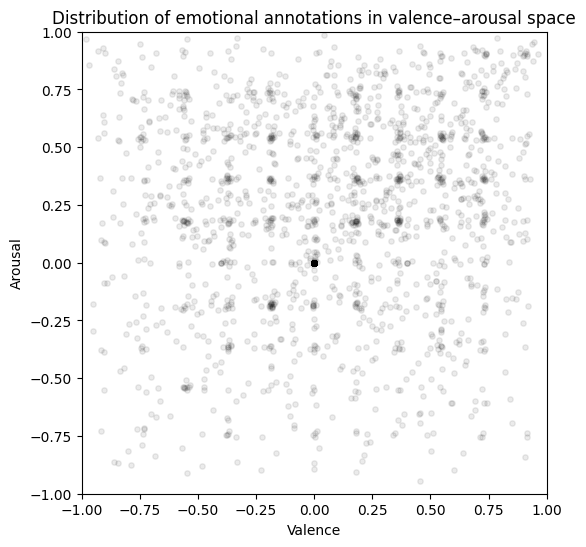

In [72]:
import matplotlib.pyplot as plt

sample = df.sample(min(3000, len(df)))

plt.figure(figsize=(6,6))

plt.scatter(
    df['valence'],
    df['arousal'],
    s=15,
    alpha=0.08,
    color="black"
)

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Valence")
plt.ylabel("Arousal")

plt.title("Distribution of emotional annotations in valence–arousal space")

plt.show()

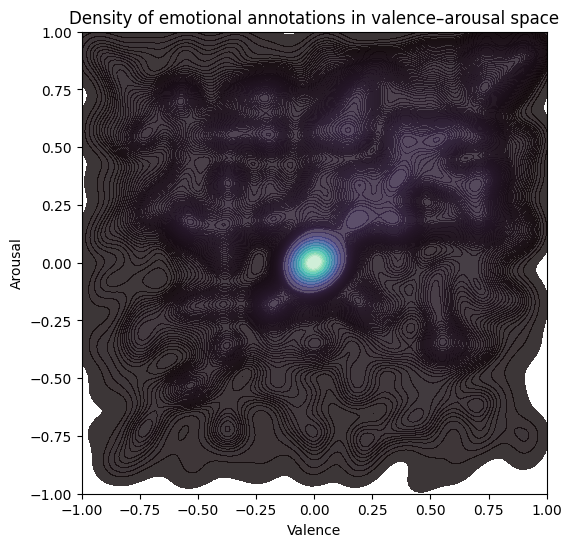

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

sns.kdeplot(
    x=df['valence'],
    y=df['arousal'],
    fill=True,
    cmap="mako",
    levels=80,
    alpha=0.8,
    bw_adjust=0.5,
    thresh=0.005
)

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Valence")
plt.ylabel("Arousal")

plt.title("Density of emotional annotations in valence–arousal space")

plt.show()

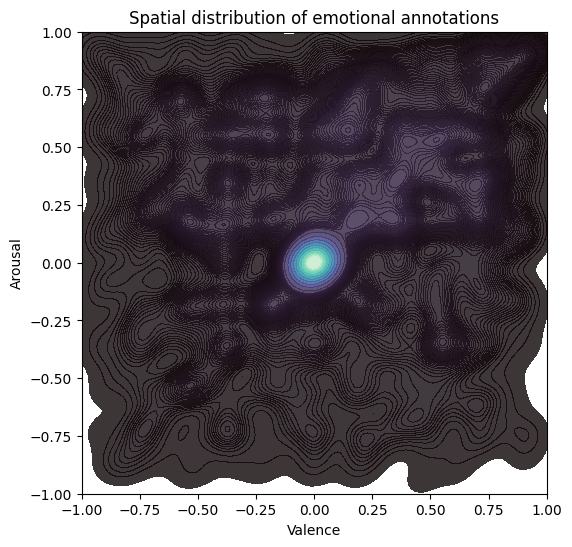

In [75]:
plt.figure(figsize=(6,6))

sns.kdeplot(
    x=df['valence'],
    y=df['arousal'],
    fill=True,
    cmap="mako",
    levels=80,
    alpha=0.8,
    bw_adjust=0.5,
    thresh=0.005
)

# plt.scatter(
#     df['valence'],
#     df['arousal'],
#     s=8,
#     alpha=0.85,
#     color='black'
# )



plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Valence")
plt.ylabel("Arousal")

plt.title("Spatial distribution of emotional annotations")

plt.show()

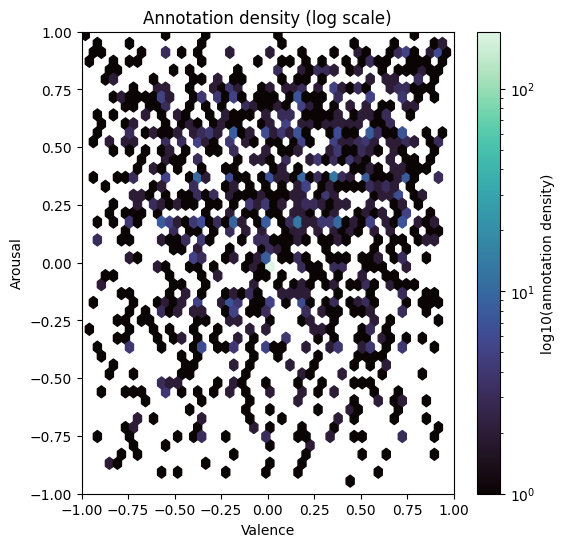

In [68]:
plt.figure(figsize=(6,6))

plt.hexbin(
    df['valence'],
    df['arousal'],
    gridsize=45,
    cmap='mako',
    bins='log'
)

plt.colorbar(label="log10(annotation density)")

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Annotation density (log scale)")

plt.show()

This workflow above ignores timestamps, aggregates each participant’s V-A ratings per excerpt, computes pairwise Euclidean distances between participants, and converts them into interpretable agreement scores. Participants provided a different number of annotations each.

In [ ]:
from itertools import combinations
import numpy as np
import pandas as pd

results = {}

for song in mean_va['song_id'].unique():

    song_df = mean_va[mean_va['song_id'] == song].set_index('participant')

    participants = song_df.index.tolist()

    if len(participants) > 1:

        pairs = list(combinations(participants, 2))

        valence_diffs = []
        arousal_diffs = []
        euclidean_dists = []

        for p1, p2 in pairs:

            v1 = song_df.loc[p1, 'valence']
            v2 = song_df.loc[p2, 'valence']

            a1 = song_df.loc[p1, 'arousal']
            a2 = song_df.loc[p2, 'arousal']

            val_diff = abs(v1 - v2)
            aro_diff = abs(a1 - a2)

            dist = np.sqrt((v1 - v2)**2 + (a1 - a2)**2)

            valence_diffs.append(val_diff)
            arousal_diffs.append(aro_diff)
            euclidean_dists.append(dist)

        results[song] = {
            "num_participants": len(participants),
            "avg_valence_diff": np.mean(valence_diffs),
            "avg_arousal_diff": np.mean(arousal_diffs),
            "avg_euclidean_distance": np.mean(euclidean_dists)
        }

    else:

        results[song] = {
            "num_participants": 1,
            "avg_valence_diff": np.nan,
            "avg_arousal_diff": np.nan,
            "avg_euclidean_distance": np.nan
        }

df_agreement = pd.DataFrame.from_dict(results, orient="index")

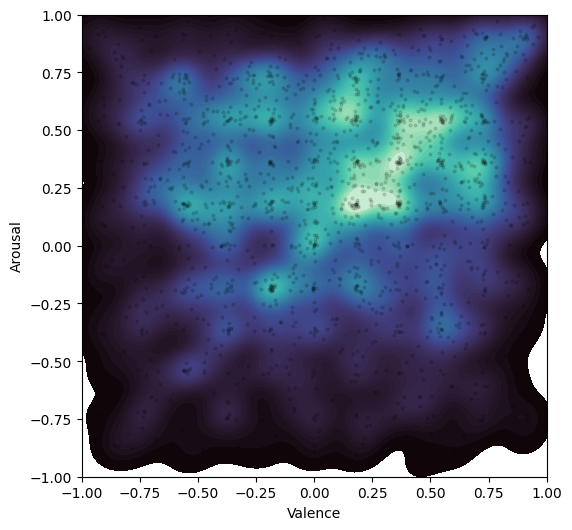

In [86]:
df_plot = df[~((df['valence'] == 0) & (df['arousal'] == 0))]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

sns.kdeplot(
    x=df_plot['valence'],
    y=df_plot['arousal'],
    fill=True,
    cmap="mako",
    levels=70,
    bw_adjust=0.5,
    thresh=0.005
)

plt.scatter(
    df_plot['valence'],
    df_plot['arousal'],
    s=4,
    alpha=0.12,
    color="black"
)

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xlabel("Valence")
plt.ylabel("Arousal")

plt.show()

# **Krippendorf:**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install krippendorff

In [ ]:
import pandas as pd
import numpy as np
import krippendorff

# ------------------------------
# 1. Load dataset
# ------------------------------
df_exp = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/all_timestamps.csv")

# Create song_id
df_exp['song_id'] = df_exp['drive_filename'].str[:-8]  # remove last 8 chars

# ------------------------------
# 2. Count unique participants per excerpt
# ------------------------------
participant_counts = df_exp.groupby('song_id')['participant'].nunique()
songs_2plus = participant_counts[participant_counts >= 2].index.tolist()
print(f"Number of excerpts with >=2 raters: {len(songs_2plus)}")

# ------------------------------
# 3. Compute mean valence/arousal per participant per excerpt
# ------------------------------
mean_va = df_exp[df_exp['song_id'].isin(songs_2plus)].groupby(
    ['song_id', 'participant']
).agg({
    'valence': 'mean',
    'arousal': 'mean'
}).reset_index()

# ------------------------------
# 4. Reshape to matrix for Krippendorff alpha
# ------------------------------
valence_matrix = mean_va.pivot(index='song_id', columns='participant', values='valence')
arousal_matrix = mean_va.pivot(index='song_id', columns='participant', values='arousal')

# Save CSV to inspect
valence_matrix.to_csv("valence_matrix.csv")
arousal_matrix.to_csv("arousal_matrix.csv")
print("Reshaped matrices saved to CSV.")

# ------------------------------
# 5. Compute Krippendorff's alpha
# ------------------------------
alpha_valence = krippendorff.alpha(valence_matrix.to_numpy(), level_of_measurement='interval')
alpha_arousal = krippendorff.alpha(arousal_matrix.to_numpy(), level_of_measurement='interval')

print(f"\nKrippendorff's alpha for valence: {alpha_valence:.3f}")
print(f"Krippendorff's alpha for arousal: {alpha_arousal:.3f}")

Number of excerpts with >=2 raters: 210
Reshaped matrices saved to CSV.

Krippendorff's alpha for valence: 0.011
Krippendorff's alpha for arousal: 0.126


In [ ]:
import pandas as pd
import numpy as np

# Load the mean valence/arousal per participant per excerpt that we already created
# mean_va has columns: ['song_id', 'participant', 'valence', 'arousal']

results = {}

for song in mean_va['song_id'].unique():
    song_df = mean_va[mean_va['song_id'] == song].set_index('participant')
    participants = song_df.index.tolist()

    if len(participants) > 1:
        # Compute pairwise Euclidean distances
        from itertools import combinations
        pairs = list(combinations(participants, 2))
        distances = [np.linalg.norm(song_df.loc[p1][['valence', 'arousal']] - song_df.loc[p2][['valence', 'arousal']])
                     for p1, p2 in pairs]
        avg_distance = np.mean(distances)
    else:
        avg_distance = np.nan  # only 1 annotator

    # Convert to agreement score (1 = perfect agreement, 0 = maximum distance possible)
    # Since V-A ranges from -1 to +1, max distance in 2D is sqrt((2)^2 + (2)^2) = sqrt(8) ≈ 2.828
    agreement_score = 1 - (avg_distance / 2.828) if not np.isnan(avg_distance) else np.nan

    results[song] = {
        'num_participants': len(participants),
        'avg_euclidean_distance': avg_distance,
        'agreement_score': agreement_score
    }

df_agreement = pd.DataFrame.from_dict(results, orient='index')
df_agreement.sort_values('agreement_score', ascending=False, inplace=True)

# Save CSV so you can check
df_agreement.to_csv("va_agreement_scores.csv")
print(df_agreement.head(30))

                                                    num_participants  \
aaronburrsirhamiltonsample                                         2   
drumdronewhiplashjustinhurwitzsample                               2   
mexicaninstituteofsoundjalalefromcocosample                        2   
daydreambelieverthemonkeeswomentalkingsample                       2   
blackwayblackcaviarwhatsupdangerspidermanintoth...                 2   
inmotiontrentreznorandatticusrossthesocialnetwo...                 3   
gunadottirtarilargohildurgunadottirsample                          2   
ludovicoeinaudilowmistvar2day1thefathersample                      2   
toystory3lefreakchicsample                                         2   
beachpukejimwilliamstitanesample                                   3   
vanmorrisonandthehealinghasbegunbelfastsample                      2   
solomonhanszimmer12yearsaslavesample                               2   
arrivaljonnygreenwoodspencersample                              

# **recalculating new csv metadata**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import unicodedata
import re

# Load CSVs with proper encoding
datasheet = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/film-emotion-music-datasheet.csv",
    encoding='latin1'  # Handles Windows-1252 / ISO-8859-1 characters
)
main_csv = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv",
    encoding='utf-8'
)

# Function to normalize filenames
def normalize_filename(name):
    # remove accents
    name = unicodedata.normalize('NFKD', str(name)).encode('ASCII', 'ignore').decode('ASCII')
    # lowercase
    name = name.lower()
    # remove non-alphanumeric characters
    name = re.sub(r'[^a-z0-9]', '', name)
    # remove mp3 extension
    name = name.replace('mp3', '')
    return name

# Apply normalization
datasheet['norm_filename'] = datasheet['Sample 2 filename:'].apply(normalize_filename)
main_csv['norm_filename'] = main_csv['file_path'].apply(normalize_filename)

# Find which tracks are actually in main CSV
merged = datasheet[datasheet['norm_filename'].isin(main_csv['norm_filename'])]
print(f"Tracks present in main CSV: {len(merged)} / {len(datasheet)}")

Tracks present in main CSV: 216 / 320


In [8]:
# Tracks in datasheet but not in main CSV
missing_tracks = datasheet[~datasheet['norm_filename'].isin(main_csv['norm_filename'])]

# Print their original filenames for inspection
print("Tracks in datasheet NOT present in main CSV:")
print(missing_tracks['Sample 2 filename:'].tolist())
# 275 out of 302 are in the final dataset.

Tracks in datasheet NOT present in main CSV:
['Conciliation_II_Parasite_Jung_Jaeil_sample_2.mp3', 'Whiplash_Overture_Justin_Hurwitz_sample_2.mp3', 'Wall-E_Thomas_Newman_sample_2.mp3', 'Into_the_Spider-Verse_Daniel_Pemberton_sample_2.mp3', 'Un_Poco_Loco_From_Coco_Anthony_Gonzalez_Gael_Garci?a_Bernal_sample_2.mp3', 'So_Long_-Randy_Newman_toy_story_3_sample_2.mp3', 'toy-story-3-le-freak_chic_sample_2.mp3', 'khaled-mouzanar-zeyn_Capernaum_sample_2.mp3', 'The_Hunt_the-end_Nikolaj_Egelund_sample_2.mp3', 'aaron-burr-sir_Hamilton_sample_2.mp3', 'audiomachine-the-big-smoke-1917_sample_2.mp3', 'Kesariya_-_Brahm?stra__Pritam_sample_2.mp3', 'Shiva_Theme_Brahma?stra__Pritam_sample_2.mp3', 'Ludovico_Einaudi_Cold_Wind_Var.2_(Day_4)_The_Father_sample_2.mp3', 'Nicholas_Britell_-_The_Middle_Of_The_World_-_Moonlight_sample_2.mp3', 'Zara_Larsson_-_Invisible_Klaus_sample_2.mp3', 'Technically,_Missing_Gone_Girl_Trent_Reznor_Atticus_Ross_sample_2.mp3', 'Sugar_Storm_Gone_Girl_Trent_Reznor_Atticus_Ross_sample_

In [12]:
import pandas as pd

# Load the cleaned datasheet
df = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/film-emotion-music-datasheet-275.csv",
    encoding="latin1"
)

# ----------------------------
# Scores vs Soundtracks
# ----------------------------
score_counts = df['Score = 0, Soundtrack = 1'].value_counts()

scores = score_counts.get(0, 0)
soundtracks = score_counts.get(1, 0)

print("Scores:", scores)
print("Soundtracks:", soundtracks)


# ----------------------------
# Sample rate counts
# ----------------------------
sr_counts = df['Sample Rate (kHz)'].value_counts()

print("\nSample Rate Counts:")
print(sr_counts)


# ----------------------------
# Genre analysis
# ----------------------------

# Split multi-tag genres into individual genres
genre_list = (
    df['Film Genre - IMDb']
    .dropna()
    .str.split()
    .explode()
)

# Count occurrences
genre_counts = genre_list.value_counts()

print("\nNumber of unique genres:", genre_counts.shape[0])

print("\nTop genres:")
print(genre_counts.head(26))

Scores: 213
Soundtracks: 52

Sample Rate Counts:
Sample Rate (kHz)
44.1    208
48.0     67
Name: count, dtype: int64

Number of unique genres: 26

Top genres:
Film Genre - IMDb
Drama          201
Comedy          59
Adventure       58
Action          47
Romance         38
Biography       35
Mystery         34
Crime           33
Sci-Fi          25
Animation       24
Thriller        23
Horror          20
Fantasy         18
Music           13
History         10
Documentary      8
War              8
Musical          6
Drama,           5
Family           5
Western          4
Sport            4
Comedy,          3
Crime,           2
Action,          2
Adventure,       2
Name: count, dtype: int64


/tmp/ipykernel_1220/760715513.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scores = score_counts.get(0, 0)
/tmp/ipykernel_1220/760715513.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  soundtracks = score_counts.get(1, 0)


In [13]:
# ---------------------------------------------------
# Unique IMDb genre label combinations
# ---------------------------------------------------

unique_genre_labels = df['Film Genre - IMDb'].dropna().nunique()

print("Unique IMDb genre label combinations:", unique_genre_labels)

Unique IMDb genre label combinations: 72


In [11]:
import pandas as pd
import re

# Load cleaned datasheet
df = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/film-emotion-music-datasheet-275.csv",
    encoding="latin1"
)

# ---------------------------------------------------
# Scores vs Soundtracks
# ---------------------------------------------------
score_counts = df['Score = 0, Soundtrack = 1'].value_counts()

scores = score_counts.get(0, 0)
soundtracks = score_counts.get(1, 0)

print("Scores:", scores)
print("Soundtracks:", soundtracks)


# ---------------------------------------------------
# Sample Rate counts
# ---------------------------------------------------
print("\nSample Rate Counts:")
print(df['Sample Rate (kHz)'].value_counts())


# ---------------------------------------------------
# Genre analysis
# ---------------------------------------------------
genre_list = (
    df['Film Genre - IMDb']
    .dropna()
    .str.split()
    .explode()
)

genre_counts = genre_list.value_counts()

print("\nUnique genres:", genre_counts.shape[0])
print("\nTop genres:")
print(genre_counts.head(20))


# ---------------------------------------------------
# Composer analysis
# ---------------------------------------------------

# Function to split multiple composers
def split_composers(text):
    if pd.isna(text):
        return []
    # split on common separators
    return re.split(r',|&| and ', text)

composer_list = (
    df['Composer/Artist']
    .apply(split_composers)
    .explode()
    .str.strip()
)

composer_counts = composer_list.value_counts()

print("\nUnique composers/artists:", composer_counts.shape[0])

print("\nTop composers:")
print(composer_counts.head(26))

Scores: 213
Soundtracks: 52

Sample Rate Counts:
Sample Rate (kHz)
44.1    208
48.0     67
Name: count, dtype: int64

Unique genres: 26

Top genres:
Film Genre - IMDb
Drama          201
Comedy          59
Adventure       58
Action          47
Romance         38
Biography       35
Mystery         34
Crime           33
Sci-Fi          25
Animation       24
Thriller        23
Horror          20
Fantasy         18
Music           13
History         10
Documentary      8
War              8
Musical          6
Drama,           5
Family           5
Name: count, dtype: int64

Unique composers/artists: 196

Top composers:
Composer/Artist
Hans Zimmer                                          19
Alexandre Desplat                                     9
JÃ³hann JÃ³hannsson                                   8
Ludwig GÃ¶ransson                                     8
Michael Giacchino                                     7
Michael Abels                                         5
Jonny Greenwood             

/tmp/ipykernel_1220/4224365590.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scores = score_counts.get(0, 0)
/tmp/ipykernel_1220/4224365590.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  soundtracks = score_counts.get(1, 0)


In [14]:
import pandas as pd

# Load CSVs
main = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv"
)

demo = pd.read_csv(
    "/content/drive/MyDrive/data-organisation-fme-2026/fme-demographics-music-sophistication.csv"
)

# Get unique participants from main dataset
main_participants = main['participant'].unique()

print("Participants in main dataset:", len(main_participants))

# Keep only matching demographics
demo_matched = demo[demo['participant-ID'].isin(main_participants)]

print("Matched demographic rows:", len(demo_matched))

Participants in main dataset: 98
Matched demographic rows: 98


In [15]:
print("\nGender:")
print(demo_matched['gender'].value_counts())

print("\nAge groups:")
print(demo_matched['age'].value_counts())

print("\nNationality:")
print(demo_matched['nationality'].value_counts())

print("\nOccupation:")
print(demo_matched['occupation'].value_counts())

print("\nFormative years location:")
print(demo_matched['formative-years'].value_counts())

print("\nAttentive listening:")
print(demo_matched['attentiveMusic'].value_counts())

print("\nCasual listening:")
print(demo_matched['casualMusic'].value_counts())


Gender:
gender
Female               32
Male                 30
female               13
male                 11
FEMALE                2
Female/non-binary     2
Personal              1
He/Him                1
Masculine             1
Cis Man               1
Femenin               1
M                     1
Name: count, dtype: int64

Age groups:
age
25-34    50
18-24    17
55-64    11
45-54     8
35-44     8
65+       4
Name: count, dtype: int64

Nationality:
nationality
British                44
british                 5
Chinese                 3
French                  3
Mexican                 2
UK                      2
mexican                 2
Portuguese              2
China                   2
MEXICAN                 2
Canadian                2
German                  2
Italian                 2
Chinese/Singaporean     1
italian                 1
USA                     1
British/Swiss           1
english                 1
Bristish                1
Spanish                 1
Ukrainian

In [16]:
import pandas as pd

# Load files
main = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv")
demo = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/fme-demographics-music-sophistication.csv")

# Match participants
main_participants = main['participant'].unique()
demo_matched = demo[demo['participant-ID'].isin(main_participants)]

print("Participants used:", len(demo_matched))


# ------------------------
# Attentive music listening
# ------------------------
print("\nAttentive Music Listening:")
print(demo_matched['attentiveMusic'].value_counts())


# ------------------------
# Casual music listening
# ------------------------
print("\nCasual Music Listening:")
print(demo_matched['casualMusic'].value_counts())


# ------------------------
# Years of musical training
# ------------------------
print("\nMusic Years:")
print(demo_matched['musicYears'].value_counts())


# ------------------------
# Importance of music
# ------------------------
print("\nMusic Importance:")
print(demo_matched['musicImportance'].value_counts())

Participants used: 98

Attentive Music Listening:
attentiveMusic
0-15       32
30-60      21
15-30      19
2-4 hrs    12
1-2hrs     11
4+ hrs      3
Name: count, dtype: int64

Casual Music Listening:
casualMusic
1-2hrs     25
4+ hrs     20
30-60      17
2-4 hrs    16
0-15       11
15-30       9
Name: count, dtype: int64

Music Years:
musicYears
0-1     32
10+     26
6-10    17
1-2     11
2-4      7
4-6      5
Name: count, dtype: int64

Music Importance:
musicImportance
10    45
8     17
9     15
7     12
5      4
6      3
3      1
4      1
Name: count, dtype: int64


In [17]:
import pandas as pd

demo = pd.read_csv("/content/drive/MyDrive/data-organisation-fme-2026/fme-demographics-music-sophistication.csv")

genres = demo['musicGenre'].dropna()

In [18]:
genres_split = genres.str.split(',')
genres_flat = genres_split.explode().str.strip().str.lower()

In [19]:
genre_map = {
    'rock':'Rock',
    'alt rock':'Rock',
    'alternative':'Rock',
    'metal':'Rock',
    'punk':'Rock',

    'electronic':'Electronic',
    'techno':'Electronic',
    'house':'Electronic',
    'edm':'Electronic',
    'drum and bass':'Electronic',
    'drum & bass':'Electronic',
    'dnb':'Electronic',
    'trance':'Electronic',

    'pop':'Pop',
    'synthpop':'Pop',

    'indie':'Indie',
    'indie rock':'Indie',
    'indie pop':'Indie',

    'classical':'Classical',
    'orchestral':'Classical',
    'baroque':'Classical',

    'jazz':'Jazz',

    'hip hop':'Hip-Hop',
    'rap':'Hip-Hop',

    'ambient':'Ambient',
    'experimental':'Experimental',

    'soundtrack':'Soundtrack',
    'film score':'Soundtrack'
}

In [20]:
def group_genre(g):
    return genre_map.get(g, g.capitalize())

grouped_genres = genres_flat.apply(group_genre)

In [21]:
genre_counts = grouped_genres.value_counts()

print(genre_counts)

musicGenre
Rock                                                     16
Pop                                                      12
Indie                                                    10
Classical                                                 6
Electronic                                                5
Hip-hop                                                   2
Funk                                                      2
Folk                                                      2
Jazz                                                      2
Jazz hip hop                                              2
Hip-Hop                                                   2
Alternative and classic...                                1
Blues                                                     1
Country                                                   1
Rocknroll                                                 1
Na                                                        1
Everything.  apart from count

In [22]:
print("Unique raw genres:", genres_flat.nunique())

Unique raw genres: 64


In [23]:
pip install pydub mutagen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 5.9 MB/s eta 0:00:00


In [35]:
from google.colab import files
uploaded = files.upload()

Saving The_Hungry_Ghost__Aaron_Cupples_Island_of_the_Hungry_Ghosts.mp3 to The_Hungry_Ghost__Aaron_Cupples_Island_of_the_Hungry_Ghosts.mp3


In [36]:
from pydub.utils import mediainfo
from mutagen import File
import pandas as pd

# Single audio file
audio_file = "The_Hungry_Ghost__Aaron_Cupples_Island_of_the_Hungry_Ghosts.mp3"

# Using pydub's mediainfo
info = mediainfo(audio_file)

# Using mutagen as fallback
f = File(audio_file)

audio_info = [{
    'file': "Spotlight_Howard_Shore.mp3",
    'format': info.get('format_name', 'unknown'),
    'sample_rate': info.get('sample_rate', 'unknown'),
    'bit_rate': info.get('bit_rate', getattr(f.info, 'bitrate', 'unknown'))
}]

# Convert to DataFrame for easy viewing
df = pd.DataFrame(audio_info)
print(df)

# Optionally, save to CSV
df.to_csv("Spotlight_Howard_Shore_metadata.csv", index=False)

                         file format sample_rate bit_rate
0  Spotlight_Howard_Shore.mp3    mp3       44100   320007


In [2]:
import pandas as pd

# Load your data
file_path = '/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv'
df = pd.read_csv(file_path)

# Drop any missing values just in case
df = df[['valence', 'arousal']].dropna()

# Define quadrants
high_high = df[(df['valence'] > 0) & (df['arousal'] > 0)]
low_high  = df[(df['valence'] < 0) & (df['arousal'] > 0)]
low_low   = df[(df['valence'] < 0) & (df['arousal'] < 0)]
high_low  = df[(df['valence'] > 0) & (df['arousal'] < 0)]

# Exact (0,0)
origin = df[(df['valence'] == 0) & (df['arousal'] == 0)]

# Print counts
print("High Valence, High Arousal:", len(high_high))
print("Low Valence, High Arousal:", len(low_high))
print("Low Valence, Low Arousal:", len(low_low))
print("High Valence, Low Arousal:", len(high_low))
print("Exactly (0,0):", len(origin))
print("Total:", len(df))

High Valence, High Arousal: 681
Low Valence, High Arousal: 449
Low Valence, Low Arousal: 226
High Valence, Low Arousal: 230
Exactly (0,0): 187
Total: 1784


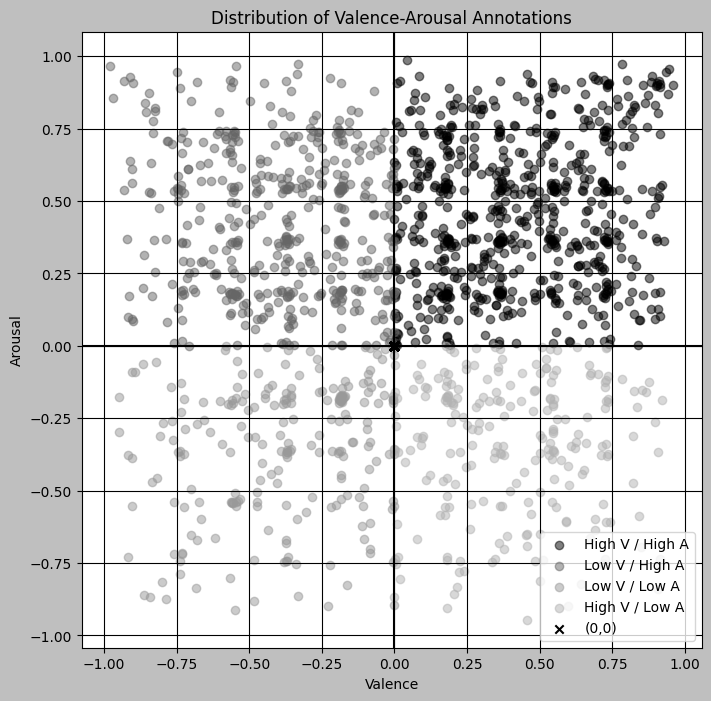

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = '/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv'
df = pd.read_csv(file_path)

df = df[['valence', 'arousal']].dropna()

# Create masks for quadrants
q1 = df[(df['valence'] > 0) & (df['arousal'] > 0)]   # High V, High A
q2 = df[(df['valence'] < 0) & (df['arousal'] > 0)]   # Low V, High A
q3 = df[(df['valence'] < 0) & (df['arousal'] < 0)]   # Low V, Low A
q4 = df[(df['valence'] > 0) & (df['arousal'] < 0)]   # High V, Low A
origin = df[(df['valence'] == 0) & (df['arousal'] == 0)]

# Plot
plt.figure(figsize=(8, 8))

plt.scatter(q1['valence'], q1['arousal'], alpha=0.5, label='High V / High A')
plt.scatter(q2['valence'], q2['arousal'], alpha=0.5, label='Low V / High A')
plt.scatter(q3['valence'], q3['arousal'], alpha=0.5, label='Low V / Low A')
plt.scatter(q4['valence'], q4['arousal'], alpha=0.5, label='High V / Low A')

# Highlight origin points
plt.scatter(origin['valence'], origin['arousal'], marker='x', label='(0,0)')

# Axis lines
plt.axhline(0)
plt.axvline(0)

# Labels
plt.xlabel('Valence')
plt.ylabel('Arousal')
plt.title('Distribution of Valence-Arousal Annotations')

plt.legend()
plt.grid(True)

plt.show()

In [11]:
import matplotlib.pyplot as plt

plt.rcdefaults()  # resets any previous style (VERY important)

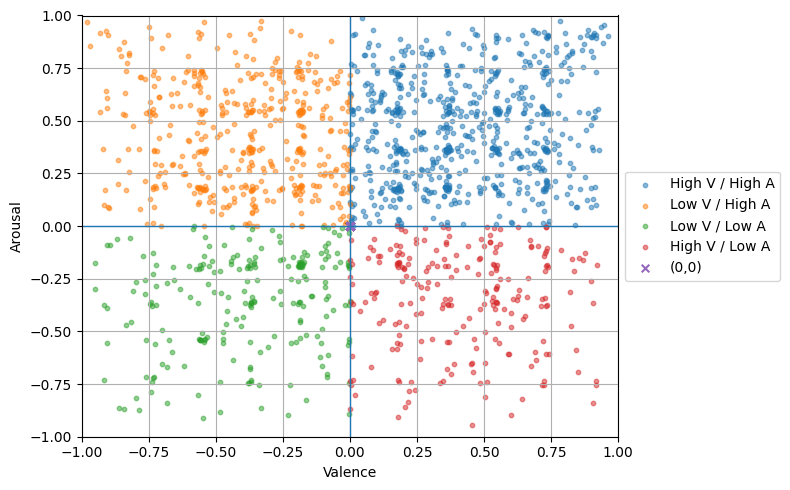

In [16]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Scatter plots with distinct colours
plt.scatter(q1['valence'], q1['arousal'], alpha=0.5, s=10, label='High V / High A')   # e.g. warm
plt.scatter(q2['valence'], q2['arousal'], alpha=0.5, s=10, label='Low V / High A')
plt.scatter(q3['valence'], q3['arousal'], alpha=0.5, s=10, label='Low V / Low A')
plt.scatter(q4['valence'], q4['arousal'], alpha=0.5, s=10, label='High V / Low A')

# Origin points (make them stand out)
plt.scatter(origin['valence'], origin['arousal'], marker='x', s=30, label='(0,0)')

# Axis lines
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

# Limits
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Labels
plt.xlabel('Valence')
plt.ylabel('Arousal')

# Legend OUTSIDE
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Grid
plt.grid(True)

# Adjust layout so legend fits
plt.tight_layout()

plt.show()

In [17]:
df[['valence', 'arousal']].describe()

,valence,arousal
count,1784.000000,1784.000000
mean,0.068812,0.192793
std,0.451205,0.419094
min,-0.980188,-0.945547
25%,-0.238340,-0.009133
50%,0.005924,0.187750
75%,0.405894,0.540078
max,0.961250,0.987969


In [18]:
import pandas as pd

file_path = '/content/drive/MyDrive/data-organisation-fme-2026/librosa_features_full_fme_dataset_MARCH_2026_NC.csv'
df = pd.read_csv(file_path)

# inspect column names first (important)
print(df.columns)

Index(['participant', 'file_path', 'timestamp', 'emotion_sentence',
       'familiarity', 'valence', 'arousal', 'timestamp.1', 'annotation_order',
       'total_annotations', 'timestamp_imputed', 'start_time', 'end_time',
       'rms', 'zcr', 'harmonic_ratio', 'percussive_ratio', 'tonnetz_mean_1',
       'tonnetz_mean_2', 'tonnetz_mean_3', 'tonnetz_mean_4', 'tonnetz_mean_5',
       'tonnetz_mean_6', 'tonnetz_var_1', 'tonnetz_var_2', 'tonnetz_var_3',
       'tonnetz_var_4', 'tonnetz_var_5', 'tonnetz_var_6', 'mfcc_mean_1',
       'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc_mean_5',
       'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8', 'mfcc_mean_9',
       'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12', 'mfcc_mean_13',
       'mfcc_var_1', 'mfcc_var_2', 'mfcc_var_3', 'mfcc_var_4', 'mfcc_var_5',
       'mfcc_var_6', 'mfcc_var_7', 'mfcc_var_8', 'mfcc_var_9', 'mfcc_var_10',
       'mfcc_var_11', 'mfcc_var_12', 'mfcc_var_13', 'self_similarity_mean',
       'self_similarity_var', 'mfcc_m

In [19]:
df = df.dropna()

# adjust column name here if needed
time_col = 'timestamp'

print(df[time_col].describe())

count    1600.000000
mean        6.993809
std         4.620760
min         0.000000
25%         3.054153
50%         6.763268
75%        10.835671
max        15.000000
Name: timestamp, dtype: float64


In [20]:
first_5s = df[df[time_col] <= 5]
total = len(df)

print("Total annotations:", total)
print("Annotations in first 5 seconds:", len(first_5s))
print("Proportion:", len(first_5s) / total)

Total annotations: 1600
Annotations in first 5 seconds: 618
Proportion: 0.38625


In [21]:
bins = [0, 2, 5, 10, 15, 30, 60]
df['time_bin'] = pd.cut(df[time_col], bins=bins)

print(df['time_bin'].value_counts().sort_index())

time_bin
(0, 2]      249
(2, 5]      324
(5, 10]     483
(10, 15]    499
(15, 30]      0
(30, 60]      0
Name: count, dtype: int64
